In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../marc/ttrpg_scraped_dataset.csv")

df.head()

,Name,Description,Average Score,Number of Reviews
0,13th Age,From the back cover:\n\nThe World Won't Save I...,7.90114,131.0
1,The 23rd Letter,From the publisher:\n\nThe time is now.\n\nPsy...,0.00000,0.0
2,2300 AD,2300AD is a hard science-fiction role-playing ...,7.28917,60.0
3,3D&T,from the manual:\nEste guia n&atilde;o inclui ...,7.00000,1.0
4,7th Sea,The first of two core rulebooks for the 7th Se...,7.57759,116.0


In [2]:
df.columns

Index(['Name', 'Description', 'Average Score', 'Number of Reviews'], dtype='object')

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("../marc/ttrpg_scraped_dataset.csv")

# Clean columns
df = df.dropna(subset=["Name", "Description"]).copy()
df["Description"] = df["Description"].astype(str)
df["Average Score"] = pd.to_numeric(df["Average Score"], errors="coerce")
df["Number of Reviews"] = pd.to_numeric(df["Number of Reviews"], errors="coerce")

df.head()

,Name,Description,Average Score,Number of Reviews
0,13th Age,From the back cover:\n\nThe World Won't Save I...,7.90114,131.0
1,The 23rd Letter,From the publisher:\n\nThe time is now.\n\nPsy...,0.00000,0.0
2,2300 AD,2300AD is a hard science-fiction role-playing ...,7.28917,60.0
3,3D&T,from the manual:\nEste guia n&atilde;o inclui ...,7.00000,1.0
4,7th Sea,The first of two core rulebooks for the 7th Se...,7.57759,116.0


distribution of average scores

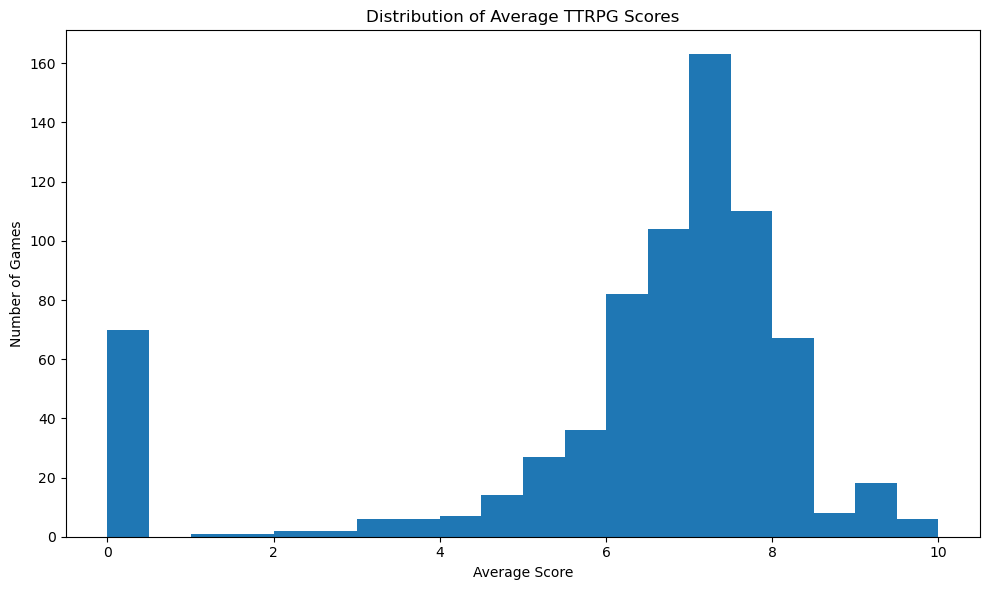

In [13]:
# This histogram shows how the average scores are distributed.
# It helps us see if most games are rated highly, poorly, or somewhere in the middle.

plt.figure(figsize=(10, 6))

df["Average Score"].dropna().plot(kind="hist", bins=20)

plt.title("Distribution of Average TTRPG Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

Top 10 Highest Rated TTRPGs

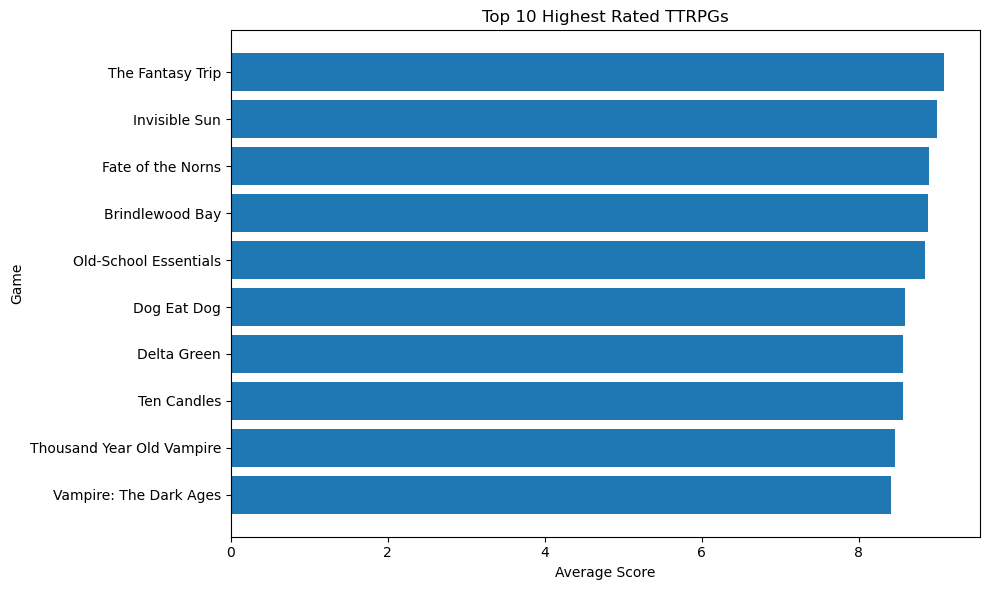

In [14]:
# This chart shows the TTRPGs with the highest average scores.
# We only include games with at least 10 reviews so that one random review does not make a game look unfairly high.

top_rated = (
    df[df["Number of Reviews"] >= 10]
    .sort_values("Average Score", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(top_rated["Name"][::-1], top_rated["Average Score"][::-1])

plt.title("Top 10 Highest Rated TTRPGs")
plt.xlabel("Average Score")
plt.ylabel("Game")
plt.tight_layout()
plt.show()

 Top 10 Most Reviewed TTRPGs

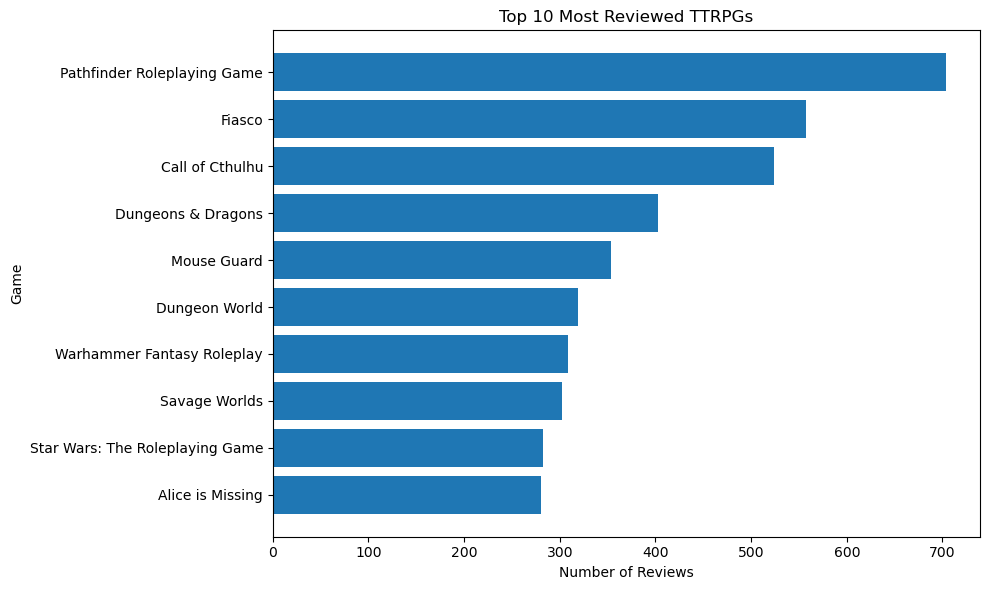

In [15]:
# This chart shows which games have the most reviews.
# A high number of reviews can suggest that the game is popular, well-known, or has more user engagement.

most_reviewed = (
    df.sort_values("Number of Reviews", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(most_reviewed["Name"][::-1], most_reviewed["Number of Reviews"][::-1])

plt.title("Top 10 Most Reviewed TTRPGs")
plt.xlabel("Number of Reviews")
plt.ylabel("Game")
plt.tight_layout()
plt.show()

Average Score vs Number of Reviews Scatter Plot

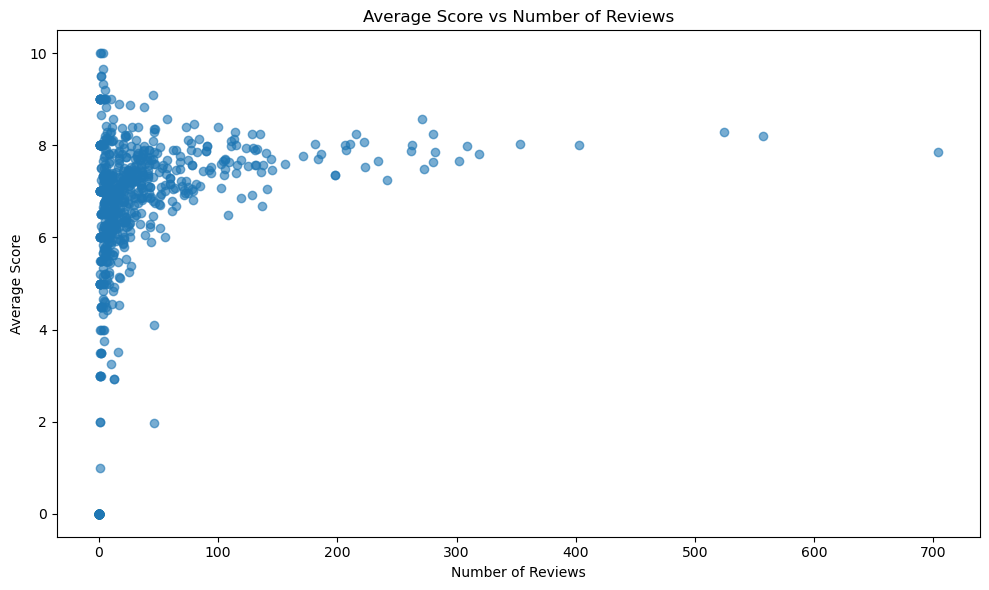

In [16]:
# This scatter plot compares each game's average score with its number of reviews.
# It helps us check if more reviewed games also tend to have higher ratings.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Number of Reviews"],
    df["Average Score"],
    alpha=0.6
)

plt.title("Average Score vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

Average Score vs Number of Reviews with Log Scale

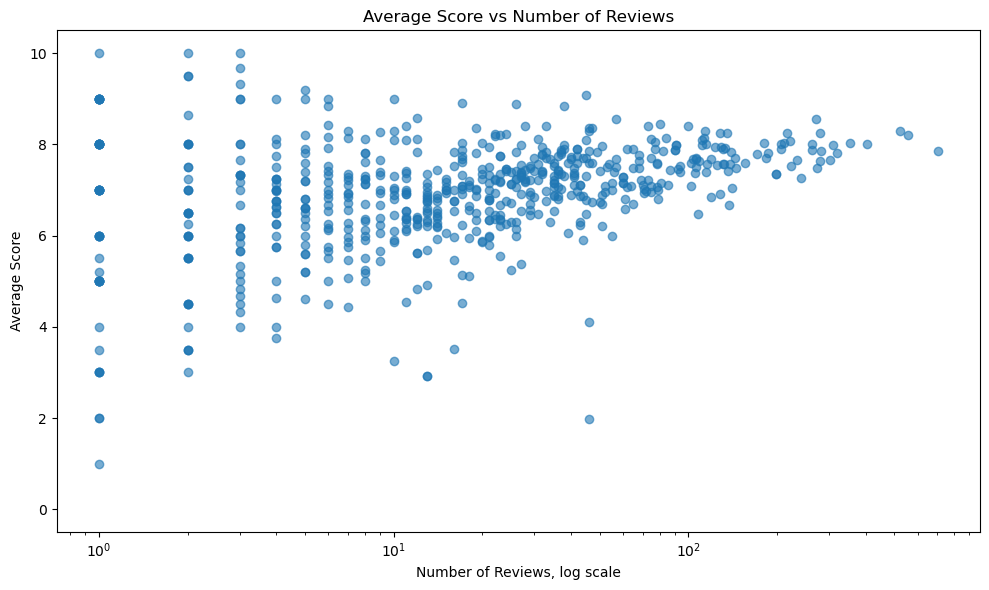

In [17]:
# This is the same scatter plot, but the x-axis uses a log scale.
# This makes the chart easier to read when some games have extremely high review counts.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Number of Reviews"],
    df["Average Score"],
    alpha=0.6
)

plt.xscale("log")
plt.title("Average Score vs Number of Reviews")
plt.xlabel("Number of Reviews, log scale")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

Description Length Distribution

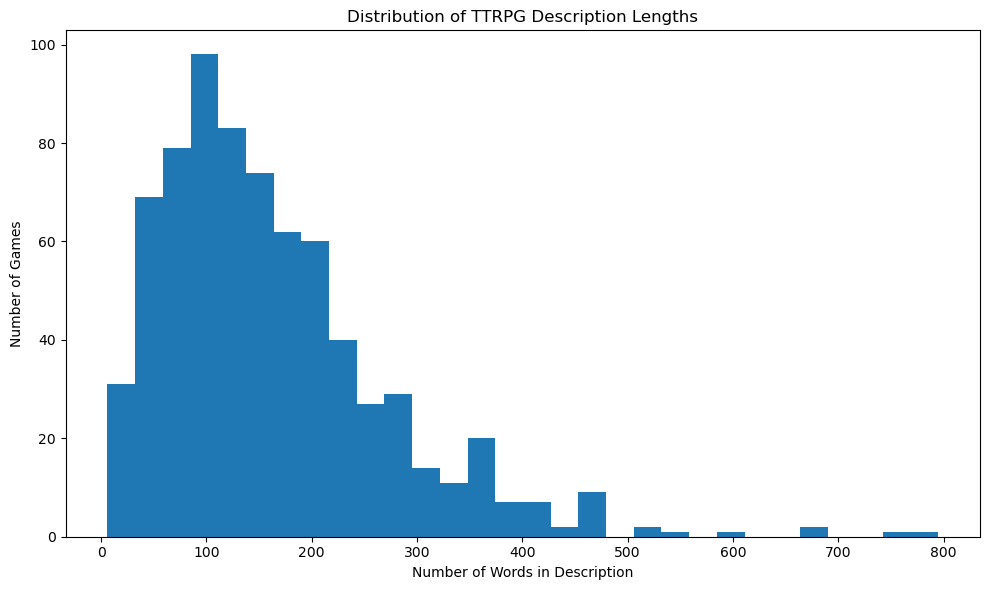

In [18]:
# This creates a new column that counts the number of words in each description.
# The chart shows whether most descriptions are short, medium, or long.

df["Description Length"] = df["Description"].str.split().str.len()

plt.figure(figsize=(10, 6))

df["Description Length"].dropna().plot(kind="hist", bins=30)

plt.title("Distribution of TTRPG Description Lengths")
plt.xlabel("Number of Words in Description")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

Average Score by Description Length

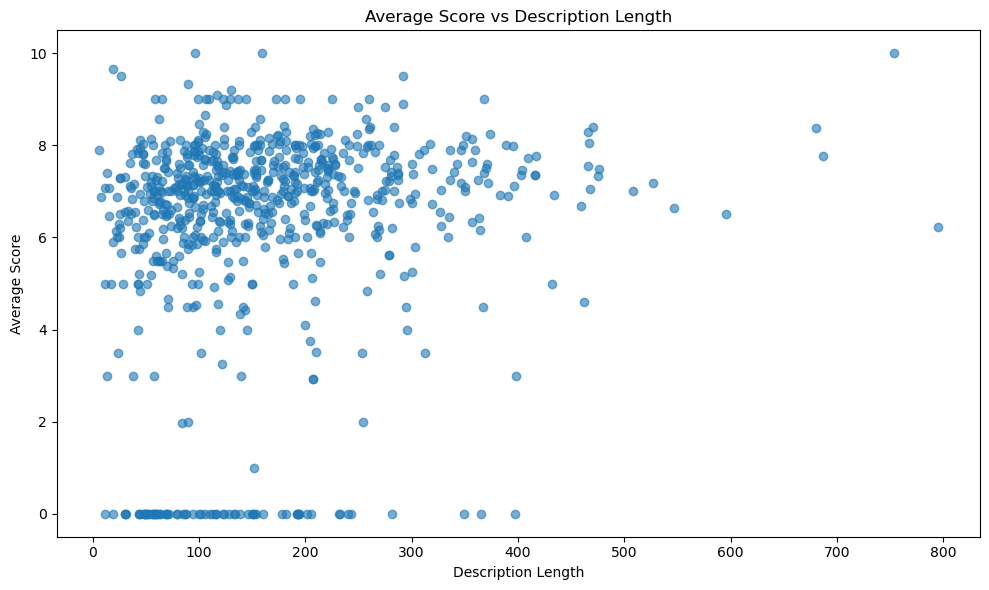

In [19]:
# This scatter plot checks if description length is related to average score.
# For example, it can show whether games with longer descriptions tend to have higher or lower ratings.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Description Length"],
    df["Average Score"],
    alpha=0.6
)

plt.title("Average Score vs Description Length")
plt.xlabel("Description Length")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

Top TF-IDF Words in Descriptions

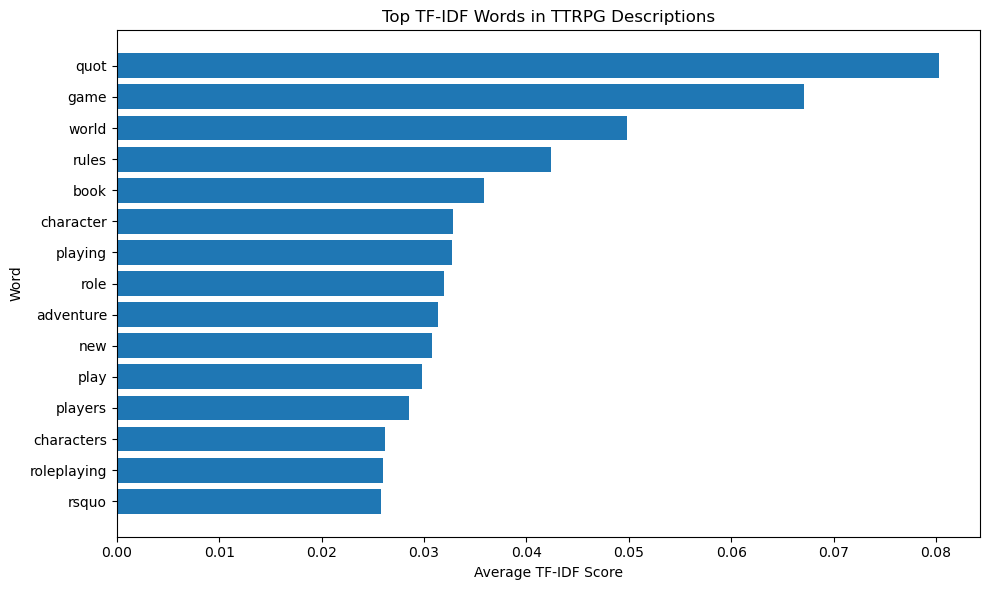

In [ ]:
# TF-IDF turns descriptions into numerical word features.
# This chart shows the words with the highest average TF-IDF scores across the dataset.
# These words help describe the common themes in the TTRPG descriptions.

vectorizer = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=5,
    max_features=1000
)

X_tfidf = vectorizer.fit_transform(df["Description"])

tfidf_scores = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "score": X_tfidf.mean(axis=0).A1
})

top_words = tfidf_scores.sort_values("score", ascending=False).head(15)

plt.figure(figsize=(10, 6))

plt.barh(top_words["word"][::-1], top_words["score"][::-1])

plt.title("Top TF-IDF Words in TTRPG Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word")
plt.tight_layout()
plt.show()